# SPDX-FileCopyrightText: 2026 NVIDIA CORPORATION & AFFILIATES
# SPDX-License-Identifier: Apache-2.0 AND CC-BY-4.0

## 许可证

除非另有说明：

- 代码单元格遵循
  [Apache 许可证 2.0](../../LICENSES/Apache-2.0.txt)。
- Markdown 及原始单元格遵循
  [知识共享署名 4.0 国际许可协议](../../LICENSES/CC-BY-4.0.txt)。
- 第三方材料保留其原始许可证，详见
  [`THIRD_PARTY_NOTICES.md`](../../THIRD_PARTY_NOTICES.md)。

版权所有 (c) 2026 NVIDIA CORPORATION & AFFILIATES。

## 5b. 迁移学习

到目前为止，我们已经在大型数据集上训练了精确的模型，也下载了无需训练即可使用的预训练模型。但如果我们找不到完全符合需求的预训练模型，也没有足够大的数据集从头训练模型，该怎么办？这时，我们可以使用一种非常有用的技术，称为[迁移学习](https://blogs.nvidia.com/blog/2019/02/07/what-is-transfer-learning/)。

在迁移学习中，我们取一个预训练模型，并在与原始训练任务有所重叠的新任务上对其进行再训练。一个很好的类比是：一位擅长绘画的艺术家想要学习炭笔画。可以想象，他在绘画中学到的技能在学习炭笔画时会非常有价值。

以深度学习为例，假设我们有一个非常擅长识别各种汽车类型的预训练模型，现在想训练一个识别摩托车类型的模型。汽车模型中学到的很多知识很可能非常有用，例如识别车灯和车轮的能力。

当我们没有大量多样化的数据集时，迁移学习尤为强大。在这种情况下，从头开始训练的模型很可能会快速记住训练数据，但无法很好地泛化到新数据。借助迁移学习，你可以提高在小数据集上训练出精确且鲁棒模型的可能性。

## 5b.1 准备工作

在开始之前，让我们先安装本实验所需的库。

In [1]:
!pip install -r ./requirements.txt -q

本实验使用 Kaggle 数据集：[Penny the Corgi](https://www.kaggle.com/datasets/danielledetering/penny-the-corgi)。请运行以下代码将其添加到数据文件夹。

In [2]:
import data

dataset_name = "danielledetering/penny-the-corgi"
source_folder = 'data/datasets/danielledetering/penny-the-corgi/versions/1/PennyClassification'
destination_folder = 'data/PennyClassification'

data.download_kagglehub_dataset(dataset_name, source_folder, destination_folder)

100%|██████████| 200M/200M [01:04<00:00, 3.25MB/s] 

Extracting files...


Success! Dataset downloaded and unzipped to: data/PennyClassification


## 5b.2 学习目标

* 为迁移学习准备预训练模型
* 在预训练模型上使用自己的小数据集进行迁移学习
* 进一步微调模型以获得更好的性能

In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.v2 as transforms
import torchvision.io as tv_io

import glob
import json
from PIL import Image

import utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


False

## 5b.3 个性化宠物门

在上一个练习中，我们使用预训练的 [ImageNet](http://www.image-net.org/) 模型来放行所有狗，但拦截其他动物。在本练习中，我们将创建一个只允许特定狗进入的宠物门。具体来说，我们将为一只名叫 Penny 的柯基犬制作一个自动宠物门。`data/corgi_door` 文件夹中有更多 Penny 的图片。

<center><img src="./Penny.jpg" width=30% /></center>

挑战在于，预训练模型并非专门用于识别这只特定的狗，而且我们只有 116 张 Penny 的图片。如果尝试用这些图片从头训练模型，会出现过拟合和泛化能力差的问题。然而，如果我们从一个擅长检测狗的预训练模型开始，就可以利用其已有知识，通过较小的数据集建立对 Penny 的泛化理解。我们可以使用迁移学习来解决这一挑战。

### 5b.3.1 下载预训练模型

[ImageNet torchvision.models](https://pytorch.org/vision/stable/models.html) 通常是计算机视觉迁移学习的良好选择，因为它们已经学会了对各种不同类型的图像进行分类。在此过程中，它们学会了检测许多不同类型的[特征](https://developers.google.com/machine-learning/glossary#)，这些特征在图像识别中具有重要价值。由于 ImageNet 模型已学会检测包括狗在内的动物，因此它特别适合用于检测 Penny 的迁移学习任务。

让我们从下载预训练模型开始。

In [4]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

# load the VGG16 network *pre-trained* on the ImageNet dataset
weights = VGG16_Weights.DEFAULT
vgg_model = vgg16(weights=weights)

下载时需要注意一个重要差异。ImageNet 模型的最后一层是包含 1000 个单元的[全连接层](https://developers.google.com/machine-learning/glossary#dense-layer)，代表数据集中 1000 个可能的类别。而在我们的情况下，我们希望它进行不同的分类：这是 Penny 还是不是？我们将添加新层来专门识别 Penny。

In [5]:
vgg_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### 5b.3.2 冻结基础模型
在将新层添加到[预训练模型](https://developers.google.com/machine-learning/glossary#pre-trained-model)之前，我们需要先执行一个重要步骤：冻结模型的预训练层。这意味着在训练时，我们不会更新预训练模型的基础层，而只更新我们在末尾添加的用于新分类任务的新层。我们冻结初始层是为了保留在 ImageNet 数据集上训练所获得的知识。如果此时解冻这些层，很可能会破坏这些宝贵的信息。之后有选项可以解冻并训练这些层，该过程称为微调。

冻结基础层只需将模型的 [requires_grad_](https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad.html) 设置为 `False` 即可。

In [6]:
vgg_model.requires_grad_(False)
print("VGG16 已冻结")

VGG16 已冻结


### 5b.3.3 添加新层

现在我们可以将新的可训练层添加到预训练模型中。这些层将提取预训练层的特征，并将其转化为对新数据集的预测。我们将向模型添加两层。在之前的课程中，我们创建了自己的[自定义模块](https://pytorch.org/tutorials/beginner/examples_nn/two_layer_net_module.html)。迁移学习模块的工作方式完全相同，可以作为[顺序模型](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)中的一层使用。

然后，我们将添加一个 `Linear` 层，将 VGG16 的全部 `1000` 个输出连接到 `1` 个神经元。

In [7]:
N_CLASSES = 1

my_model = nn.Sequential(
    vgg_model,
    nn.Linear(1000, N_CLASSES)
)

my_model.to(device)

Sequential(
  (0): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16): M

如果我们想验证 VGG 层是否已被冻结，可以遍历模型的[参数](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html)。

In [8]:
for idx, param in enumerate(my_model.parameters()):
    print(idx, param.requires_grad)

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 True
33 True


如果我们确实想让 VGG 层可训练，可以对 `vgg_model` 将 `requires_grad_` 设置为 `True`。

In [9]:
vgg_model.requires_grad_(True)
print("VGG16 已解冻")
for idx, param in enumerate(my_model.parameters()):
    print(idx, param.requires_grad)

VGG16 已解冻
0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 True
28 True
29 True
30 True
31 True
32 True
33 True


但目前我们只希望训练新添加的层，因此我们将关闭其他层的训练。

In [10]:
vgg_model.requires_grad_(False)
print("VGG16 已冻结")

VGG16 已冻结


### 5b.3.4 编译模型

与之前的练习一样，我们需要为模型配置损失函数和评估指标。这里需要做一些不同的选择。在之前的情况下，我们的分类问题有很多类别，因此选择了分类交叉熵来计算损失。而在本例中，我们只有一个二分类问题（是 Penny 还是不是），因此将使用[二元交叉熵](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)。关于两者差异的详细信息，请参见[这里](https://gombru.github.io/2018/05/23/cross_entropy_loss/)。我们还将使用二元准确率代替传统准确率。

通过设置 `from_logits=True`，我们告知[损失函数](https://gombru.github.io/2018/05/23/cross_entropy_loss/)输出值尚未归一化（例如未经过 softmax 处理）。

In [11]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = Adam(my_model.parameters())
my_model = my_model.to(device)

## 5b.4 数据增强

与之前的课程一样，我们将创建一个自定义 [Dataset](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) 来读取 Penny（及非 Penny）的图片。首先，我们从 VGG `weights` 中获取预处理变换列表。

In [12]:
pre_trans = weights.transforms()

### 5b.4.1 数据集

与之前课程从 DataFrame 中读取数据不同，我们将直接读取图像文件，并根据文件路径推断 `label`。

In [13]:
DATA_LABELS = ["Penny", "Not_Penny"] 
    
class MyDataset(Dataset):
    def __init__(self, data_dir):
        self.imgs = []
        self.labels = []
        
        for l_idx, label in enumerate(DATA_LABELS):
            data_paths = glob.glob(data_dir + label + '/*.jpg', recursive=True)
            for path in data_paths:
                img = Image.open(path)
                self.imgs.append(pre_trans(img).to(device))
                self.labels.append(torch.tensor(l_idx).to(device).float())


    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]
        return img, label

    def __len__(self):
        return len(self.imgs)

### 5b.4.2 数据加载器

有了自定义 Dataset 类之后，让我们创建 [DataLoaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders)。

In [14]:
n = 32
data_path = "data/PennyClassification/"
dataset = MyDataset(data_path)

train_N = int(0.8 * len(dataset))
valid_N = len(dataset) - train_N
train_dataset, valid_dataset = random_split(dataset, [train_N, valid_N])

train_loader = DataLoader(train_dataset, batch_size=n, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=n)

### 5b.4.3 数据增强

让我们应用一些数据增强，以便模型能更好地识别 Penny。这次我们有彩色图像，因此可以充分利用 [ColorJitter](https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_illustrations.html#colorjitter)。

In [15]:
IMG_WIDTH, IMG_HEIGHT = (224, 224)

random_trans = transforms.Compose([
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.8, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.2, saturation=.2, hue=.2)
])

## 5b.5 训练循环

我们将使用与之前大致相同的训练循环，但有一些细微差异。首先，由于使用了[二元交叉熵](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)作为损失函数，`get_batch_accuracy` 函数会有所不同。我们可以将输出通过 [sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) 函数处理，但从数学角度来看，有更高效的方法。

当模型 `output` 大于 `0` 时，经过 sigmoid 函数后结果接近 `1`；当模型 `output` 小于 `0` 时，经过 sigmoid 函数后结果接近 `0`。因此，我们只需检查模型输出是否大于（[gt](https://pytorch.org/docs/stable/generated/torch.gt.html)）`0`，即可判断预测偏向哪个类别。

In [16]:
def get_batch_accuracy(output, y, N):
    zero_tensor = torch.tensor([0]).to(device)
    pred = torch.gt(output, zero_tensor)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

我们还添加了打印最后一组梯度的部分，以展示只有新添加的层在学习。

In [17]:
def train(model, check_grad=False):
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = torch.squeeze(model(random_trans(x)))
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    if check_grad:
        print('最后一组梯度：')
        for param in model.parameters():
            print(param.grad)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

取消注释以下代码以查看模型梯度的示例。由于 VGG16 以 1000 个神经元结尾，下一层中单个神经元连接了 1000 个权重，因此会打印大量数字！

In [ ]:
#train(my_model, check_grad=True)

`validate` 函数基本保持不变：

In [18]:
def validate(model):
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)[:,0]
            loss += loss_function(output, y.float()).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

关键时刻：模型能学会识别 Penny 吗？

In [19]:
epochs = 10

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train(my_model, check_grad=False)
    validate(my_model)

Epoch: 0
Train - Loss: 3.2595 Accuracy: 0.6894
Valid - Loss: 0.8876 Accuracy: 0.8485
Epoch: 1
Train - Loss: 2.2707 Accuracy: 0.7879
Valid - Loss: 0.7319 Accuracy: 0.8485
Epoch: 2
Train - Loss: 2.2451 Accuracy: 0.7652
Valid - Loss: 0.7053 Accuracy: 0.8485
Epoch: 3
Train - Loss: 2.0107 Accuracy: 0.7424
Valid - Loss: 0.7721 Accuracy: 0.8788
Epoch: 4
Train - Loss: 1.4656 Accuracy: 0.8712
Valid - Loss: 0.9854 Accuracy: 0.8788
Epoch: 5
Train - Loss: 1.7347 Accuracy: 0.8106
Valid - Loss: 0.9469 Accuracy: 0.9091
Epoch: 6
Train - Loss: 1.8280 Accuracy: 0.8182
Valid - Loss: 0.7475 Accuracy: 0.8485
Epoch: 7
Train - Loss: 2.5188 Accuracy: 0.8409
Valid - Loss: 0.7526 Accuracy: 0.8485
Epoch: 8
Train - Loss: 1.6298 Accuracy: 0.8333
Valid - Loss: 0.7695 Accuracy: 0.8182
Epoch: 9
Train - Loss: 1.0817 Accuracy: 0.8939
Valid - Loss: 0.8001 Accuracy: 0.8182


## 5b.6 结果讨论

训练集和验证集的准确率应该都相当高。这是一个非常棒的结果！我们能够在小数据集上进行训练，但由于从 ImageNet 模型迁移了知识，模型能够达到较高的准确率并具有良好的泛化能力。这意味着它对 Penny 和非 Penny 的动物都有很好的识别能力。

如果你看到验证准确率有所波动，这也没关系。下一节我们将介绍一种改进模型的技术。

## 5b.7 微调模型

现在新层已经训练完成，我们可以应用最后一个技巧来改进模型，称为[微调](https://developers.google.com/machine-learning/glossary#f)。为此，我们解冻整个模型，并以非常小的[学习率](https://developers.google.com/machine-learning/glossary#learning-rate)再次训练。这将使基础预训练层以非常小的步幅进行调整，从而小幅提升模型性能。由于 VGG16 是一个相对较大的模型，较小的学习率也有助于防止过拟合。

需要注意的是，这一步骤只能在冻结层的模型完全训练之后进行。我们之前添加到模型中的未训练线性层是随机初始化的，这意味着它需要大量更新才能正确分类图像。通过[反向传播](https://developers.google.com/machine-learning/glossary#backpropagation)过程，最后几层的大幅初始更新可能也会导致预训练层的大幅更新，从而破坏那些重要的预训练特征。然而，现在最后几层已经训练收敛，对整个模型的任何更新都会小得多（尤其是在很小的学习率下），不会破坏早期层的特征。

让我们尝试解冻预训练层，然后对模型进行微调：

In [20]:
# Unfreeze the base model
vgg_model.requires_grad_(True)
optimizer = Adam(my_model.parameters(), lr=.000001)

In [21]:
epochs = 2

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train(my_model, check_grad=False)
    validate(my_model)

Epoch: 0
Train - Loss: 1.1115 Accuracy: 0.9242
Valid - Loss: 0.7989 Accuracy: 0.8182
Epoch: 1
Train - Loss: 1.7697 Accuracy: 0.8561
Valid - Loss: 0.7944 Accuracy: 0.8182


在这种情况下，我们只训练几个 `epochs`。因为 VGG16 是一个相当大的模型，在这个数据集上训练太长时间可能会导致过拟合。

## 5b.8 查看预测结果

现在我们有了一个训练良好的模型，是时候为 Penny 创建宠物门了！我们可以先查看模型的预测结果。我们将以与上一个宠物门相同的方式对图像进行预处理。

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image)

In [23]:
def make_prediction(file_path):
    show_image(file_path)
    image = Image.open(file_path)
    image = pre_trans(image).to(device)
    image = image.unsqueeze(0)
    output = my_model(image)
    prediction = output.item()
    return prediction

在几张图片上试试，看看预测结果：

In [24]:
make_prediction('data/PennyClassification/Penny/006.JPG')

-3.722757339477539

-0.275249183177948

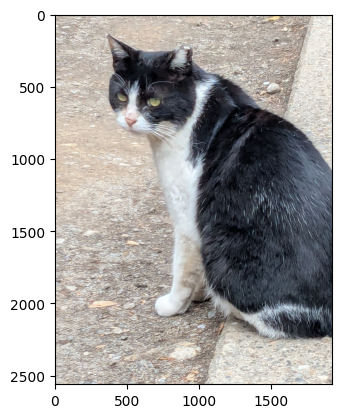

In [25]:
make_prediction('data/PennyClassification/Not_Penny/021.jpg')

看起来负数预测表示是 Penny，正数预测表示是其他动物。我们可以利用这一信息让宠物门只允许 Penny 进入！

## 5b.9 练习：Penny 的宠物门

填写以下代码以实现 Penny 的宠物门：

In [26]:
def corgi_doggy_door(image_path):
    pred = make_prediction(image_path)
    if FIXME:
        print("是 Penny！让她进来！")
    else:
        print("这不是 Penny！不让进！")

### 5b.9.1 解答

点击下面的省略号查看解答。

In [27]:
# SOLUTION
def corgi_doggy_door(image_path):
    pred = make_prediction(image_path)
    if pred < 0:
        print("是 Penny！让她进来！")
    else:
        print("这不是 Penny！不让进！")

让我们试试看！

这不是 Penny！不让进！


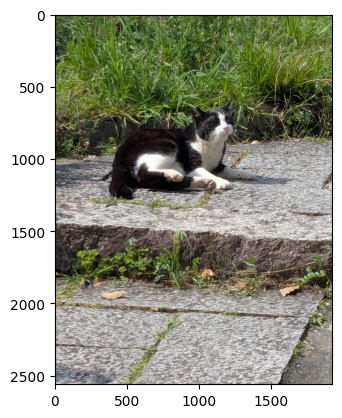

In [28]:
corgi_doggy_door('data/PennyClassification/Not_Penny/042.jpg')

是 Penny！让她进来！


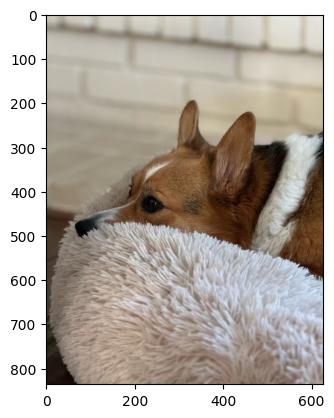

In [29]:
corgi_doggy_door('data/PennyClassification/Penny/030.jpg')

## 5b.10 总结

做得很好！借助迁移学习，你已经用非常小的数据集构建了一个高精度模型。这是一项极其强大的技术，可以决定一个项目是成功落地还是举步维艰。希望这些技术能在你未来遇到类似情况时发挥作用！

仍有提升空间。如果你想进一步提高准确率，可以尝试将 [Stanford Dogs Dataset](https://www.kaggle.com/datasets/jessicali9530/stanford-dogs-dataset) 添加到 `Not_Penny` 数据中。

### 5b.10.1 清理内存
在继续之前，请执行以下单元格以释放 GPU 内存。

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

/var/folders/_3/mjgw3qtn5yb10vqcz71qlz5c0000gn/T/ipykernel_70028/1401414292.py:2: DeprecationWarning: `IPython.Application` is only a re-export of `traitlets.config.application.Application`; import it from traitlets directly. Accessing it here triggers an import of `IPython.core.application`, which is no longer imported when IPython is -- import that module explicitly if you rely on that import happening, in particular if you also rely on other submodules being transitively imported as a side effect.
  app = IPython.Application.instance()


{'status': 'ok', 'restart': True}

: 

### 5b.10.2 下一步

到目前为止，本课程的重点主要放在图像分类上。在下一节中，为了给你提供更全面的深度学习介绍，我们将转换方向，探讨处理序列数据的方法，这需要一种不同的方式。